In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization, Input
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.initializers import orthogonal
from tensorflow.keras.regularizers import l2, l1, l1_l2
from scikeras.wrappers import KerasClassifier #This is for classification
from scikeras.wrappers import KerasRegressor #This is for Regression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
import yfinance as yf  # For downloading stock data
from skopt import BayesSearchCV
from tensorflow.keras.callbacks import Callback
from skopt.space import Categorical, Real


2025-05-02 17:22:07.909395: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

# class PrintEpochCallback(Callback):
#     def on_epoch_end(self, epoch, logs=None):
#         logs = logs or {}
#         print(f"Epoch {epoch+1}: loss={logs.get('loss')}, val_loss={logs.get('val_loss')}")

#Removing warnings
import os
import logging
import warnings

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# Suppress joblib & loky warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="joblib.externals.loky.process_executor")

# Download Apple stock data (AAPL) from Yahoo Finance
stock_data = yf.download("AAPL", start="1980-12-16", end="2025-03-23")

data = pd.DataFrame(stock_data)
# data = data.drop(['Volume'],axis=1)

# Feature Engineering
data['Close_AVG'] = stock_data['Close'].rolling(window=5).mean().fillna(0)
data['High_AVG'] = stock_data['High'].rolling(window=5).mean().fillna(0)
data['Low_AVG'] = stock_data['Low'].rolling(window=5).mean().fillna(0)
data['Open_AVG'] = stock_data['Open'].rolling(window=5).mean().fillna(0)
data['Momentum_Close'] = stock_data['Close'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_High'] = stock_data['High'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_Low'] = stock_data['Low'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_Open'] = stock_data['Open'].diff().fillna(0)  # Replace NaN with 0
data['Volatility_Close'] = stock_data['Close'].rolling(window=5).std().fillna(0)
data['Volatility_High'] = stock_data['High'].rolling(window=5).std().fillna(0)
data['Volatility_Low'] = stock_data['Low'].rolling(window=5).std().fillna(0)
data['Volatility_Open'] = stock_data['Open'].rolling(window=5).std().fillna(0)
data['ROC'] = (stock_data['Close'].pct_change() * 100).fillna(0)  # Rate of Change in %
data['Volume_Change'] = stock_data['Volume'].pct_change().fillna(0)
data['Close_Lag'] = stock_data['Close'].shift(1).fillna(0)
data['High_Lag'] = stock_data['High'].shift(1).fillna(0)
data['Low_Lag'] = stock_data['Low'].shift(1).fillna(0)
data['Open_Lag'] = stock_data['Open'].shift(1).fillna(0)

# data['Close_Upper'] = data['Close_AVG'] + stock_data['Close'].rolling(window=5).std().fillna(0).reindex(data.index) * 2
# data['Close_Lower'] = data['Close_AVG'] - stock_data['Close'].rolling(window=5).std().fillna(0) * 2
# data['High_Upper'] = data['High_AVG'] + stock_data['High'].rolling(window=5).std().fillna(0) * 2
# data['High_Lower'] = data['High_AVG'] - stock_data['High'].rolling(window=5).std().fillna(0) * 2
# data['Low_Upper'] = data['Low_AVG'] + stock_data['Low'].rolling(window=5).std().fillna(0) * 2
# data['Low_Lower'] = data['Low_AVG'] - stock_data['Low'].rolling(window=5).std().fillna(0) * 2
# data['Open_Upper'] = data['Open_AVG'] + stock_data['Open'].rolling(window=5).std().fillna(0) * 2
# data['Open_Lower'] = data['Open_AVG'] - stock_data['Open'].rolling(window=5).std().fillna(0) * 2

# Use only the 'Close' price for prediction
df_list = data.values.tolist()  
df_list = np.array(df_list, dtype=np.float64)  # Convert list to NumPy array

# Replace -inf with -257 and inf with 257
df_list[np.isneginf(df_list)] = -257
df_list[np.isposinf(df_list)] = 257

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
sequence_length = 2
num_features = 23 #For each feature added or dropped, adjust this feature(column) by either reducing or increasing

# Create sequences of past stock prices
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

batch_one_marker = int(len(df_list) * 0.7)
batch_two_marker = int(len(df_list) * 0.9)

X_train_unscaled = df_list[:batch_one_marker].reshape(-1, num_features)
X_test_unscaled = df_list[batch_one_marker - sequence_length:batch_two_marker].reshape(-1, num_features)
X_val_unscaled = df_list[batch_two_marker - sequence_length:].reshape(-1, num_features)

#############
# from sklearn.preprocessing import QuantileTransformer
# scaler = QuantileTransformer(output_distribution='normal')  #'uniform' or 'normal'
# X_train_scaled = scaler.fit_transform(X_train_unscaled)
# X_test_scaled = scaler.transform(X_test_unscaled)
# X_val_scaled = scaler.transform(X_val_unscaled)
#############

scaler = RobustScaler(quantile_range=(1.0, 99.0))
X_train_scaled = scaler.fit_transform(X_train_unscaled)
X_test_scaled = scaler.transform(X_test_unscaled)
X_val_scaled = scaler.transform(X_val_unscaled)

X_train, y_train = create_sequences(X_train_scaled, sequence_length)
X_test, y_test = create_sequences(X_test_scaled, sequence_length)
val_x, val_y = create_sequences(X_val_scaled, sequence_length)

prediction_data = val_x[-2]
Actual_Next_Day_Data = val_x[-1]
prediction_Data_Unseen_Day = val_x[-1]

X_train = X_train.reshape(X_train.shape[0], sequence_length, num_features)
X_test = X_test.reshape(X_test.shape[0], sequence_length, num_features)
val_x = val_x.reshape(val_x.shape[0], sequence_length, num_features)

# Print the shapes
print(f"Train shape x: {X_train.shape}, Test shape x: {y_train.shape}")
print(f"Validation shape x: {X_test.shape}, Validation shape y: {y_test.shape}")
print(f"Train shape y: {val_x.shape}, Test shape y: {val_y.shape}")

Train shape x: (7807, 2, 23), Test shape x: (7807, 23)
Validation shape x: (2232, 2, 23), Validation shape y: (2232, 23)
Train shape y: (1116, 2, 23), Test shape y: (1116, 23)


In [4]:

# # scaler_standard = StandardScaler()
# # data_scaled = scaler_standard.fit_transform(df_list)

# scaler_standard = RobustScaler()
# data_scaled = scaler_standard.fit_transform(df_list)

# # Create sequences of past stock prices
# def create_sequences(data, seq_length):
#     X, y = [], []
#     for i in range(len(data) - seq_length):
#         X.append(data[i:i+seq_length])
#         y.append(data[i+seq_length])
#     return np.array(X), np.array(y)

# # Define sequence length (how many past days to look at)
# sequence_length = 2
# num_features = 23

# # Create training sequences
# X, y = create_sequences(data_scaled, sequence_length)

# prediction_data = X[-2]
# Actual_Next_Day_Data = X[-1]

# # Split data into training and testing sets
# train_size = int(len(X) * 0.8)
# X_train, X_test = X[:train_size], X[train_size:]
# y_train, y_test = y[:train_size], y[train_size:]

# train_size = int(len(X_train) * 0.9)
# X_train, val_x = X_train[:train_size], X_train[train_size:]
# y_train, val_y = y_train[:train_size], y_train[train_size:]

# X_train = X_train.reshape(X_train.shape[0], sequence_length, num_features)
# val_x = val_x.reshape(val_x.shape[0], sequence_length, num_features)
# X_test = X_test.reshape(X_test.shape[0], sequence_length, num_features)

# # Print the shapes
# print(f"Train shape x: {X_train.shape}, Test shape x: {X_test.shape}")
# print(f"Validation shape x: {val_x.shape}, Validation shape y: {val_y.shape}")
# print(f"Train shape y: {y_train.shape}, Test shape y: {y_test.shape}")



Fitting 2 folds for each of 1 candidates, totalling 2 fits
[CV] END batch_size=32, epochs=10, model__delta=0.5, model__dense_neurons=500, model__dropout_rate=0.6, model__kernel_initializer=glorot_normal, model__learning_rate=0.0005207044851623737, model__lstm_neurons=1000, model__optimizer=adam, model__reg=0.01; total time=81.0min
[CV] END batch_size=32, epochs=10, model__delta=0.5, model__dense_neurons=500, model__dropout_rate=0.6, model__kernel_initializer=glorot_normal, model__learning_rate=0.0005207044851623737, model__lstm_neurons=1000, model__optimizer=adam, model__reg=0.01; total time=82.3min
Best Parameters: OrderedDict({'batch_size': 32, 'epochs': 10, 'model__delta': 0.5, 'model__dense_neurons': 500, 'model__dropout_rate': 0.6, 'model__kernel_initializer': 'glorot_normal', 'model__learning_rate': 0.0005207044851623737, 'model__lstm_neurons': 1000, 'model__optimizer': 'adam', 'model__reg': 0.01})
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - loss: 0.0330 - mae: 0.0856 

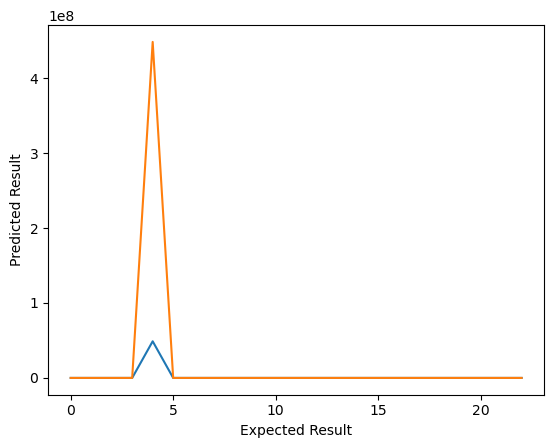

In [5]:
# #Use this if you just want to see the program run with parameters that gives results that are close to the expected value

def random_model_function(optimizer='adam', lstm_neurons=1024, dense_neurons=256, learning_rate=0.0001, dropout_rate=0.5, reg=0.10, kernel_initializer='glorot_normal', delta=1.0):
    # Define LSTM Model
    model = Sequential([
        Input(shape=(sequence_length, num_features)),
        Bidirectional(LSTM(lstm_neurons, return_sequences=True, kernel_initializer=kernel_initializer, activity_regularizer=l2(reg), recurrent_initializer=orthogonal())),  # First LSTM layer , input_shape=(sequence_length, num_features)
        #BatchNormalization(),
        Dropout(dropout_rate),
        Bidirectional(LSTM(lstm_neurons, return_sequences=True, kernel_initializer=kernel_initializer, activity_regularizer=l2(reg), recurrent_initializer=orthogonal())), # Second LSTM layer 
        #BatchNormalization(),#,
        Dropout(dropout_rate),
        Bidirectional(LSTM(lstm_neurons, return_sequences=False, kernel_initializer=kernel_initializer, activity_regularizer=l2(reg), recurrent_initializer=orthogonal())),
        Dropout(dropout_rate),
        Dense(dense_neurons, activation='relu'),  # Fully connected layer
        Dropout(dropout_rate),
        Dense(num_features, activation='linear')  # Output layer (predicting 19 values representing each feature)
    ])

    if optimizer == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    # Compile the model
    #optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=Huber(delta=1.0), metrics=['mae'])
    return model

#learning_rate_values = np.round(np.logspace(np.log10(0.0001), np.log10(0.1), num=100), 4)

# random_model = KerasRegressor(model=random_model_function, verbose=0)
random_param_grid = {
    'model__optimizer': Categorical(['adam']),  # Different optimizers
    'model__lstm_neurons': Categorical([500, 1000]),  # Number of neurons in the hidden layer
    'model__dense_neurons': Categorical([500]),
    'batch_size': Categorical([32]),  # Batch size for training
    'epochs': Categorical([5,10]),  # Number of training epochs
    'model__learning_rate': Real(0.0001, 0.01, prior="log-uniform"),  # Continuous log-uniform search
    'model__delta': Categorical([0.5,1.0,1.5]),  # Continuous log-uniform search
    #'model__learning_rate': Categorical(learning_rate_values),  # Continuous log-uniform search
    'model__dropout_rate': Categorical([0.5,0.6]),
    'model__reg': Categorical([0.01, 0.001]),
    'model__kernel_initializer': Categorical(['glorot_normal'])
}

#############################
keras_regressor = KerasRegressor(model=random_model_function, verbose=0)
bayes_search = BayesSearchCV(estimator=keras_regressor, 
                                       search_spaces=random_param_grid,
                                       n_iter=1,  # Number of parameter combinations to sample, try 30 for best results
                                       cv=2, 
                                       verbose=2,
                                       n_jobs=-1)
#############################

# Set up Bayesian Optimization
# bayes_search = BayesSearchCV(
#     estimator=keras_regressor,
#     search_spaces=param_space,
#     n_iter=30,  # Number of trials (reduce/increase as needed)
#     cv=3,  # Cross-validation
#     n_jobs=-1,  # Use all available cores
#     verbose=1
# )
#print(keras_regressor.get_params().keys())
# Min model training
#random_grid_result = randomized_search.fit(X_train, y_train, **{'validation_data': (val_x, val_y)}, callbacks=[PrintEpochCallback()])
random_grid_result = bayes_search.fit(X_train, y_train, **{'validation_data': (val_x, val_y)})#, callbacks=[PrintEpochCallback()])

#Min Best Parameters
# print("Best Parameters:", random_grid_result.best_params_)
# random_params = random_grid_result.best_params_

#Min Best Parameters
print("Best Parameters:", random_grid_result.best_params_)
random_params = random_grid_result.best_params_

def random_build_best_model():
    model = Sequential([
        Input(shape=(sequence_length, num_features)),
        Bidirectional(LSTM(random_params['model__lstm_neurons'], return_sequences=True, kernel_initializer=random_params['model__kernel_initializer'], activity_regularizer=l2(random_params['model__reg']), recurrent_initializer=orthogonal())),  # First LSTM layer
        #BatchNormalization(),
        Dropout(random_params['model__dropout_rate']),
        Bidirectional(LSTM(random_params['model__lstm_neurons'], return_sequences=True, kernel_initializer=random_params['model__kernel_initializer'], activity_regularizer=l2(random_params['model__reg']), recurrent_initializer=orthogonal())), # Second LSTM layer 
        #BatchNormalization(),#recurrent_initializer=orthogonal(),
        Dropout(random_params['model__dropout_rate']),
        Bidirectional(LSTM(random_params['model__lstm_neurons'], return_sequences=False, kernel_initializer=random_params['model__kernel_initializer'], activity_regularizer=l2(random_params['model__reg']), recurrent_initializer=orthogonal())), #Third LSTM layer
        Dropout(random_params['model__dropout_rate']),
        Dense(random_params['model__dense_neurons'], activation='relu'),  # Fully connected layer
        Dropout(random_params['model__dropout_rate']),
        Dense(num_features, activation='linear')  # Output layer (predicting 19 values representing each feature)
    ])

    if random_params['model__optimizer'] == 'adam':
        optimizer = Adam(learning_rate=random_params['model__learning_rate'])
    elif random_params['model__optimizer'] == 'sgd':
        optimizer = SGD(learning_rate=random_params['model__learning_rate'])
    # Compile the model
    #optimizer = tf.keras.optimizers.Adam(learning_rate=random_params['model__learning_rate'])
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    model.compile(optimizer=optimizer, loss=Huber(delta=random_params['model__delta']), metrics=['mae'])
    return model

random_best_model = random_build_best_model()

random_best_model.fit(X_train, y_train, 
               epochs=random_params['epochs'], 
               batch_size=random_params['batch_size'], 
               validation_data=(val_x, val_y))

#Evaluating the results of the min_best_model
test_loss, test_acc = random_best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f} and the Test Loss is: {test_loss:.2f}")

#Predicting the result of the reduced hyperparameter tuning
prediction_data = np.expand_dims(prediction_data, axis=0)  # Add batch dimension to make it (1, sequence_length, num_features) 
print(prediction_data.shape)

predicted = random_best_model.predict(prediction_data)

# Inverse transform predictions back to original price scale
predicted_prices = scaler.inverse_transform(predicted)
pre_prediction = scaler.inverse_transform(prediction_data.reshape(-1,num_features))
Expected_result = scaler.inverse_transform(Actual_Next_Day_Data.reshape(-1,num_features))
Diff_result = Expected_result[1] - predicted_prices
print(f"This is the scaled prediction_data {prediction_data}")
print(f"This is the prediction Data {pre_prediction}\n")
print(f"This is the predicted price {predicted_prices}")
print(f"This is the Expected Price {Expected_result[1]}")
print(f"This is the difference between the expected and predicted price {Diff_result}")
plt.plot(Expected_result[1])
plt.plot(predicted_prices[0])
plt.xlabel("Expected Result")
plt.ylabel("Predicted Result")
plt.show()